In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
table = np.loadtxt(f'output.txt', delimiter='\t', skiprows=1)
n = table[:,0]
pi_est = table[:,1]
pi_err = table[:,2]
pi_std = table[:,3]
exec_time = table[:,4]
sample_time = table[:,5]
sample_rate = table[:,6]

In [6]:
# fit log-log data for standard deviation
logn = np.log(n)
logsigma = np.log(pi_std)

# perform linear regression using numpy polyfit with covariance
coeffs, cov = np.polyfit(logn, logsigma, 1, cov=True)
alpha = -coeffs[0]
logA = coeffs[1]
A = np.exp(logA)

# compute uncertainties from covariance matrix
slope_err = np.sqrt(cov[0,0])
intercept_err = np.sqrt(cov[1,1])
alpha_err = slope_err
A_err = A * intercept_err  # propagate from logA

print(f"Fitted A = {A:.3f} ± {A_err:.3f}")
print(f"Fitted alpha = {alpha:.3f} ± {alpha_err:.3f}")
print(f"Relative error in alpha = {abs(alpha-0.5)/0.5:.2%}")

# create smooth curve for the fit
n_line = np.linspace(n.min(), n.max(), 100)
sigma_fit = A * n_line**(-alpha)

# extrapolate to 12 digits of accuracy (~1e-12 error)
target = 1e-12
n_req = (A/target)**(1/alpha)
mem_req_gb = n_req * 16 / 1e9  # 2 float64 values (16 bytes) per sample
print(f"Estimated samples for {target:.0e} error = {n_req:.2e}")
print(f"Memory required for {n_req:.2e} samples = {n_req*16/1e9:.2e} GB")
print(f"Memory required relative to RAM on this computer = {100*mem_req_gb/64:.2e} %")

cpp_sample_rate = 6.956083e7 # sample rate recorded with C++ method for n = 1e9
serial_time_req = n_req / cpp_sample_rate
print(f"Estimated serial time for {n_req:.2e} samples using C++ method = {serial_time_req:.2e} seconds = {serial_time_req/(365.25*24*3600):.2e} years")
print(f"Number of cores required to parallelize C++ method for runtime of 1 year = serial time / 1 year = {serial_time_req/(365.25*24*3600):.2e}")


Fitted A = 2.038 ± 0.497
Fitted alpha = 0.522 ± 0.017
Relative error in alpha = 4.41%
Estimated samples for 1e-12 error = 3.80e+23
Memory required for 3.80e+23 samples = 6.07e+15 GB
Memory required relative to RAM on this computer = 9.49e+15 %
Estimated serial time for 3.80e+23 samples using C++ method = 5.46e+15 seconds = 1.73e+08 years
Number of cores required to parallelize C++ method for runtime of 1 year = serial time / 1 year = 1.73e+08


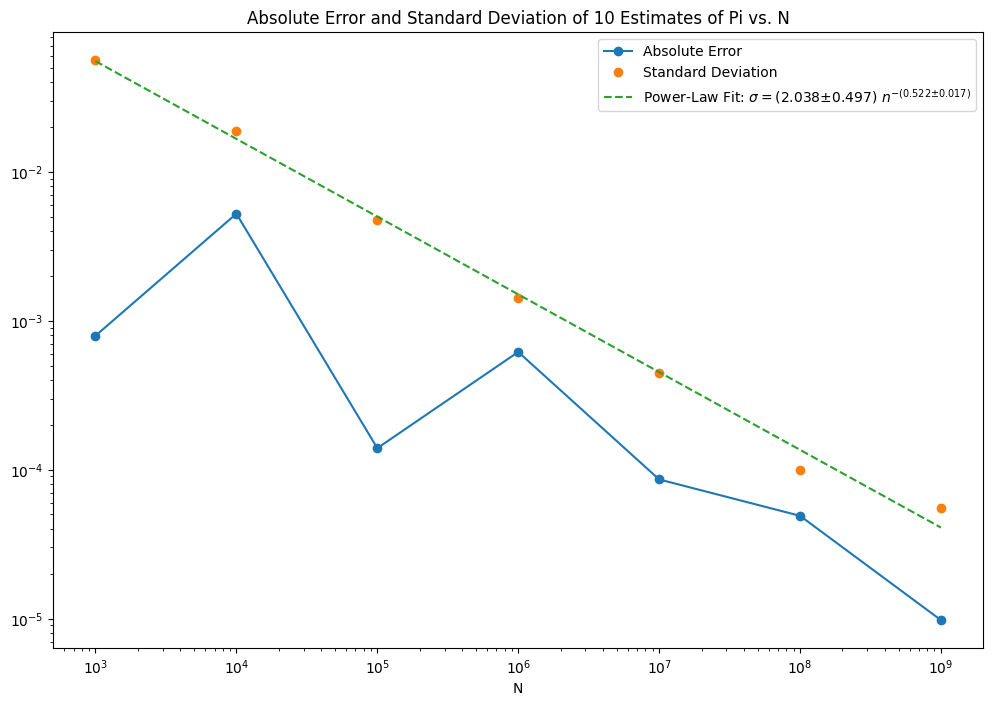

In [5]:
plt.figure(figsize=(12, 8))
plt.loglog(n, pi_err, 'o-', label='Absolute Error')
plt.loglog(n, pi_std, 'o', label='Standard Deviation')
plt.loglog(n_line, sigma_fit, '--', label=f'Power-Law Fit: $\\sigma = ({A:.3f} ± {A_err:.3f}) \\ n^{{-({alpha:.3f} ± {alpha_err:.3f})}}$')
plt.xlabel('N')
plt.title('Absolute Error and Standard Deviation of 10 Estimates of Pi vs. N')
plt.legend()
plt.savefig(f'plot.pdf', bbox_inches="tight")
plt.show()